# Supply Chain Performance Analysis: Shipping Reliability & Revenue Impact
### DataCo Global Supply Chain Dataset (2015–2018)

**Objective:** Quantify how often shipments arrive late, how much revenue is tied up in those late
shipments, where the problem is concentrated (by shipping mode and region), and forecast near-term
order volume so operations/finance teams can plan capacity.

**Structure:**
1. Data Loading & Cleaning
2. EDA — Shipping Performance & Late Delivery Rates
3. EDA — Revenue at Risk
4. EDA — Regional & Shipping Mode Bottlenecks
5. Time Series Analysis & Forecasting
6. Executive Summary (to be completed with your own interpretation)


## 1. Setup & Data Loading

We load the raw order-level data and the accompanying data dictionary (column meanings).


In [1]:
# Core libraries for data handling, plotting, and stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot styling: consistent look across all charts in this notebook
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load the main transactional dataset and the data dictionary
df = pd.read_excel('DataCoSupplyChainDataset.xlsx')
data_dict = pd.read_excel('DescriptionDataCoSupplyChain.xlsx')

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 180,519  |  Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-03-02 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 2. Data Cleaning

Three things need fix before any analysis :

1. **Mixed date formats** — the order/shipping date columns contain a mix of text strings and
   proper datetime objects. We standardize both to real datetimes.
2. **PII columns** — this dataset includes customer email, password, first/last name, street
   address, and zip code. None of these are needed for supply chain analysis, and dropping them
   is good practice before sharing or publishing a notebook.
3. **Duplicates / missing values** — a quick integrity check before we trust any numbers.

In [3]:
# Fix 1: standardize both date columns to real datetime objects
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print("Order date range:", df['order date (DateOrders)'].min(), "to", df['order date (DateOrders)'].max())

Order date range: 2015-01-01 00:00:00 to 2018-12-01 23:51:00


In [4]:
# Fix 2: drop personally identifiable information (PII) columns.
# These add no analytical value and shouldn't be carried into a shared notebook.
pii_columns = ['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
               'Customer Street', 'Customer Zipcode', 'Order Zipcode', 'Product Image']

df = df.drop(columns=pii_columns)
print(f"Dropped {len(pii_columns)} PII/unneeded columns. Remaining columns: {df.shape[1]}")

Dropped 8 PII/unneeded columns. Remaining columns: 45


In [5]:
# Fix 3: integrity check — duplicate rows and missing values
print("Duplicate rows:", df.duplicated().sum())

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(missing)

Duplicate rows: 0



Columns with missing values:
Product Description    180519
dtype: int64


## 3. EDA — Shipping Performance & Late Delivery Rates

`Delivery Status` classifies every order into one of four outcomes. We start with the headline
number: **what fraction of all orders arrived late?**

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Overall late delivery rate: 54.8%


/tmp/ipykernel_534/828386643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, palette='viridis')


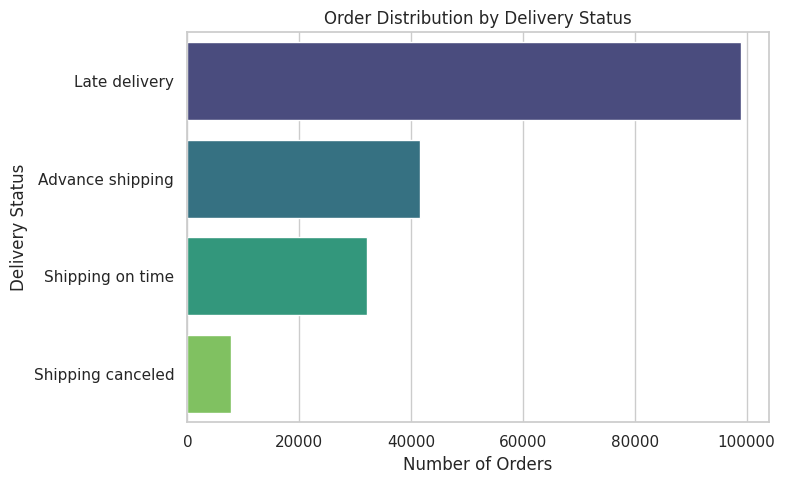

In [6]:
status_counts = df['Delivery Status'].value_counts()
print(status_counts)

late_rate = (df['Delivery Status'] == 'Late delivery').mean() * 100
print(f"\nOverall late delivery rate: {late_rate:.1f}%")

# Visualize the split
plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='viridis')
plt.title('Order Distribution by Delivery Status')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

## 4. EDA — Revenue at Risk

Here 55% of orders are late which tells us there's a *frequency* problem. The next question a
business stakeholder actually cares about is *money*: how much revenue sits inside those late
orders, and is the company's premium shipping actually delivering on its promise?

In [7]:
late_orders = df[df['Delivery Status'] == 'Late delivery']

revenue_at_risk = late_orders['Sales'].sum()
total_revenue = df['Sales'].sum()
pct_at_risk = revenue_at_risk / total_revenue * 100

print(f"Total revenue (all orders):  ${total_revenue:,.0f}")
print(f"Revenue tied to late orders: ${revenue_at_risk:,.0f}")
print(f"Share of total revenue at risk from late delivery: {pct_at_risk:.1f}%")

Total revenue (all orders):  $36,784,735
Revenue tied to late orders: $20,126,395
Share of total revenue at risk from late delivery: 54.7%


                total_orders  late_orders       revenue  late_pct
Shipping Mode                                                    
First Class            27814        26513  5.674370e+06      95.3
Second Class           35216        26987  7.145445e+06      76.6
Same Day                9737         4454  1.942529e+06      45.7
Standard Class        107752        41023  2.202239e+07      38.1


/tmp/ipykernel_534/1875876398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mode_summary['late_pct'], y=mode_summary.index, palette='rocket')


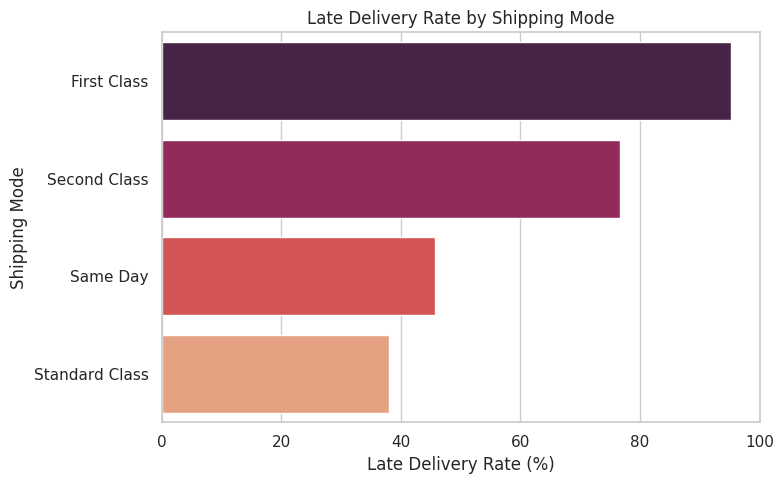

In [8]:
# Is premium shipping actually faster? Compare late-rate by Shipping Mode.
mode_summary = df.groupby('Shipping Mode').agg(
    total_orders=('Order Id', 'count'),
    late_orders=('Late_delivery_risk', 'sum'),
    revenue=('Sales', 'sum')
)
mode_summary['late_pct'] = (mode_summary['late_orders'] / mode_summary['total_orders'] * 100).round(1)
mode_summary = mode_summary.sort_values('late_pct', ascending=False)
print(mode_summary)

plt.figure(figsize=(8, 5))
sns.barplot(x=mode_summary['late_pct'], y=mode_summary.index, palette='rocket')
plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

**Finding** `First Class` shipping — the option customers pay a premium
which infact has the *highest* late rate of all four modes, well above `Standard Class`which directly implies customers are paying more for faster shipping and receiving
worse on-time performance than the cheapest option. 

### Delay magnitude check 

So far `Delivery Status` only tells us *whether* an order was late, not *by how much*.
We compute an actual delay-in-days figure (`Days for shipping (real) - Days for shipment
(scheduled)`) to get magnitude, and check whether it reveals anything the late/not-late
flag hides.

In [9]:
# Compute delay magnitude in days (positive = later than scheduled)
df['delay_days'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Look at the full distribution of delay_days WITHIN each shipping mode
for mode in df['Shipping Mode'].unique():
    counts = df.loc[df['Shipping Mode'] == mode, 'delay_days'].value_counts().sort_index()
    print(f"{mode}:")
    print(counts.to_dict())
    print()

Standard Class:
{-2: 21666, -1: 21700, 0: 21535, 1: 21111, 2: 21740}

First Class:
{1: 27814}

Second Class:
{0: 7138, 1: 7065, 2: 6978, 3: 7052, 4: 6983}

Same Day:
{0: 5080, 1: 4657}



**Finding**

The delay pattern within each shipping mode is as follows:

- **First Class: every single order has `delay_days = 1`** — not "usually," literally all
  27,814 of them.
- Standard Class, Second Class, and Same Day each split almost *perfectly evenly* across a
  small fixed set of delay values (e.g. Standard Class is split roughly equally across
  −2, −1, 0, 1, 2 days).




## 5. EDA — Regional & Market Bottlenecks

Next question: is the late-delivery problem concentrated in specific regions or markets (which
would point to a logistics/warehouse issue), or is it spread evenly everywhere (which would point
to a company-wide process issue)?

In [10]:
region_summary = df.groupby('Order Region').agg(
    total_orders=('Order Id', 'count'),
    late_orders=('Late_delivery_risk', 'sum')
)
region_summary['late_pct'] = (region_summary['late_orders'] / region_summary['total_orders'] * 100).round(1)
region_summary = region_summary.sort_values('late_pct', ascending=False)
print(region_summary)

                 total_orders  late_orders  late_pct
Order Region                                        
Central Africa           1677          972      58.0
South Asia               7731         4350      56.3
East Africa              1852         1036      55.9
South of  USA            4045         2256      55.8
Western Europe          27109        15140      55.8
Eastern Europe           3920         2182      55.7
East of USA              6915         3849      55.7
Southeast Asia           9539         5297      55.5
West Asia                6009         3322      55.3
Central Asia              553          306      55.3
US Center                5887         3252      55.2
Central America         28341        15518      54.8
North Africa             3232         1762      54.5
Southern Europe          9431         5129      54.4
South America           14935         8111      54.3
Eastern Asia             7280         3955      54.3
West of USA              7993         4313    

              total_orders  late_orders  late_pct
Market                                           
Europe               50252        27743      55.2
Pacific Asia         41260        22712      55.0
USCA                 25799        14138      54.8
Africa               11614         6340      54.6
LATAM                51594        28044      54.4


/tmp/ipykernel_534/3724938288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_summary['late_pct'], y=market_summary.index, palette='mako')


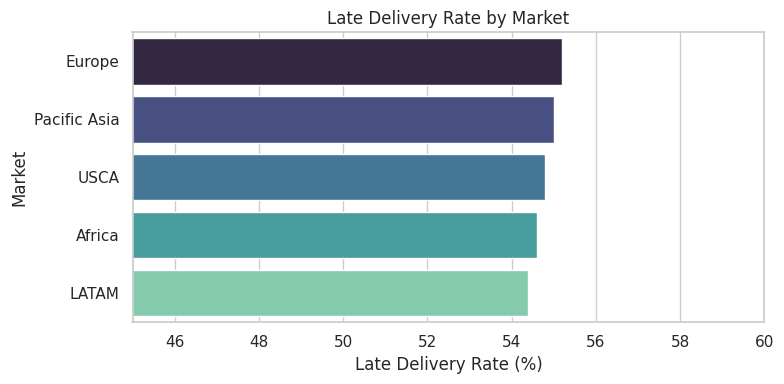

In [11]:
market_summary = df.groupby('Market').agg(
    total_orders=('Order Id', 'count'),
    late_orders=('Late_delivery_risk', 'sum')
)
market_summary['late_pct'] = (market_summary['late_orders'] / market_summary['total_orders'] * 100).round(1)
market_summary = market_summary.sort_values('late_pct', ascending=False)
print(market_summary)

plt.figure(figsize=(8, 4))
sns.barplot(x=market_summary['late_pct'], y=market_summary.index, palette='mako')
plt.title('Late Delivery Rate by Market')
plt.xlabel('Late Delivery Rate (%)')
plt.xlim(45, 60)
plt.tight_layout()
plt.show()

**Finding:** unlike shipping mode, region and market show almost no variation —
every region and every market sits in a narrow 54–58% late band. This is itself a finding,
it suggests the problem is **systemic** (a company wide fulfillment/scheduling issue), not
localized to specific warehouses or geographies. 

### Absolute revenue at risk by region

The rate table above shows late delivery is roughly the same everywhere (~54–58%) —
This chart adds a different view: which regions have the most *dollar value* sitting in late orders. A region can rank high here simply because
it has more total orders, not because it's worse at delivering on time. The two charts
answer different questions rate tells us *where the problem is*, this tells us
*where the money is* 

/tmp/ipykernel_534/518969695.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_dollar_risk.values, y=region_dollar_risk.index, palette='Oranges_r')


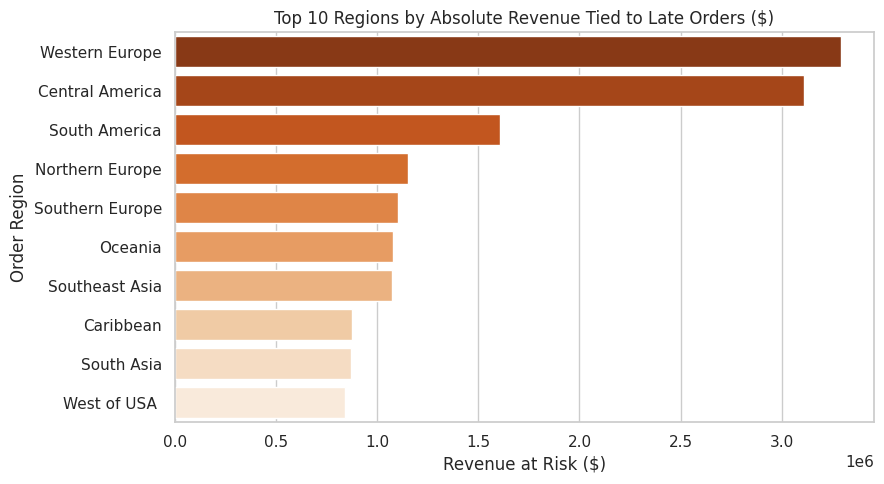

In [12]:
# Absolute revenue tied up in late orders, by region (NOT a rate — a dollar total)
region_dollar_risk = (
    df[df['Late_delivery_risk'] == 1]
    .groupby('Order Region')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=region_dollar_risk.values, y=region_dollar_risk.index, palette='Oranges_r')
plt.title('Top 10 Regions by Absolute Revenue Tied to Late Orders ($)')
plt.xlabel('Revenue at Risk ($)')
plt.tight_layout()
plt.show()

**Finding** Regions like Western  Europe top this list mainly because they have the *most total orders*, not because they
have a worse late rate .

## 6. Time Series Analysis & Forecasting
Forecasting monthly order volume, which operations and finance teams can use for staffing and inventory planning.

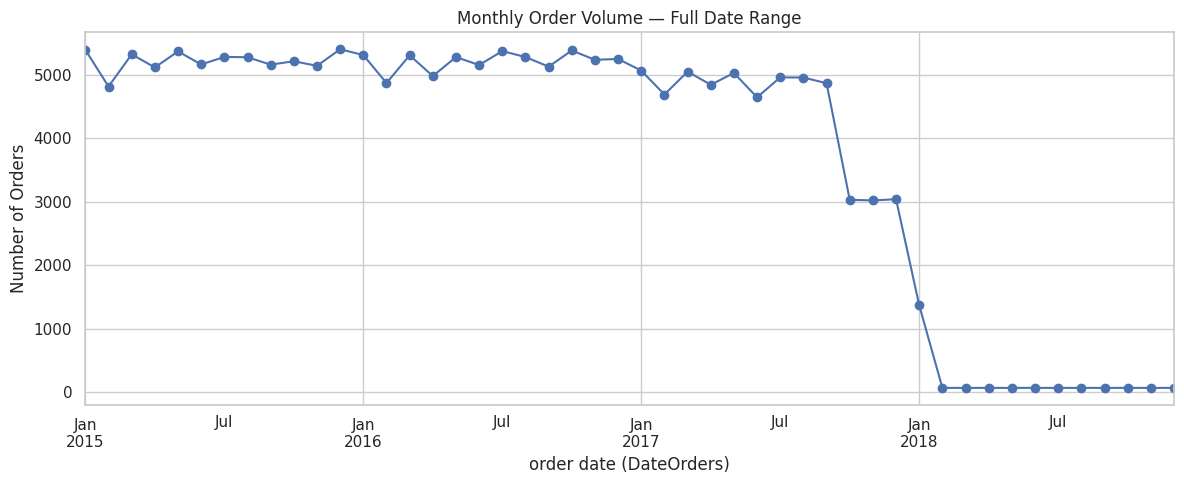

In [13]:
# Resample order dates to monthly order counts (order VOLUME over time)
monthly_orders = df.set_index('order date (DateOrders)').resample('ME').size()

plt.figure(figsize=(12, 5))
monthly_orders.plot(marker='o')
plt.title('Monthly Order Volume — Full Date Range')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Data quality issue** The chart above shows ordervolume collapsing to almost nothing after late 2017. This isn't a real collapse in business
demand it's a **data collection cutoff** in the source file Hence We ,restrict the time series to the reliable window before the cutoff.

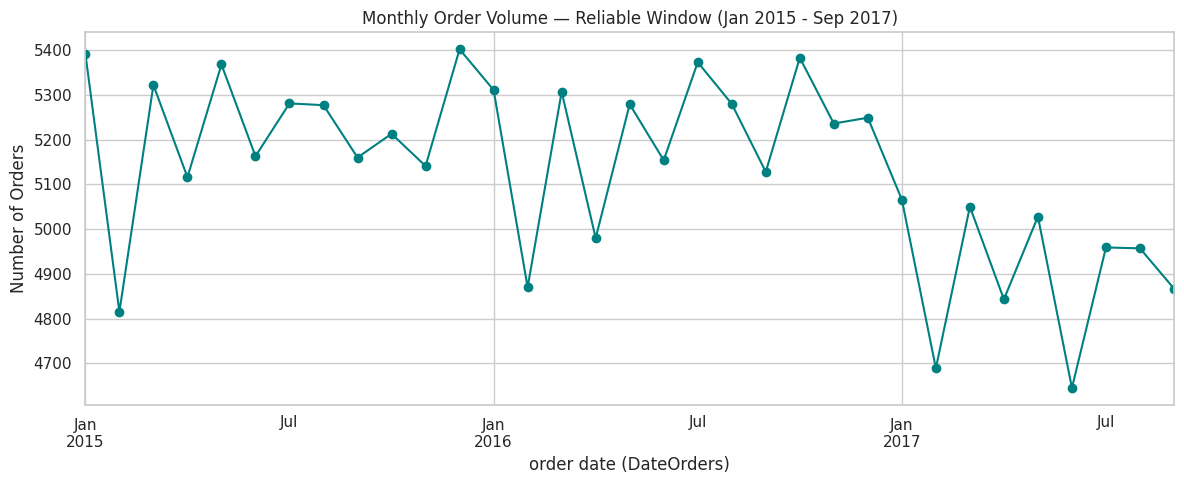

Using 33 months of reliable data


In [14]:
# Restrict to the reliable window (verified visually above): Jan 2015 - Sep 2017
monthly_orders_reliable = monthly_orders['2015-01-01':'2017-09-30']

plt.figure(figsize=(12, 5))
monthly_orders_reliable.plot(marker='o', color='teal')
plt.title('Monthly Order Volume — Reliable Window (Jan 2015 - Sep 2017)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f"Using {len(monthly_orders_reliable)} months of reliable data")

### Seasonal decomposition

We split the series into **trend** (long-term direction), **seasonal** (repeating yearly pattern),
and **residual** (what's left over / noise). 

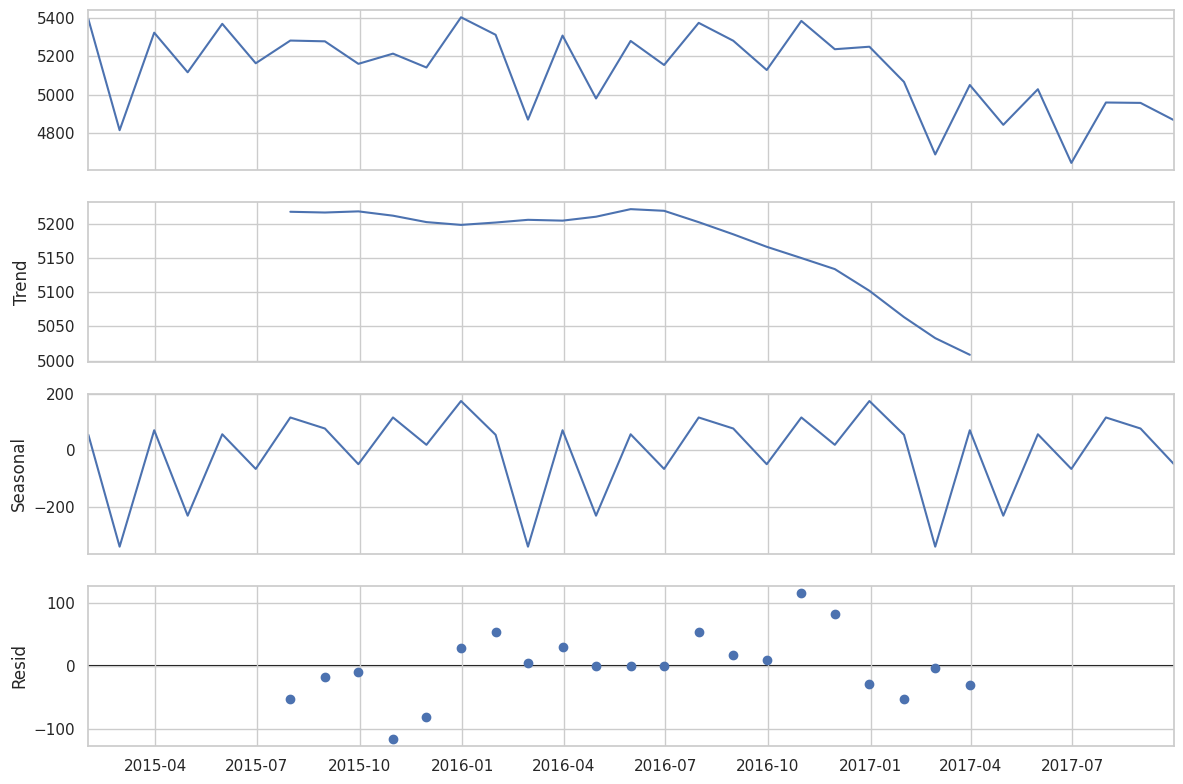

In [15]:
decomposition = seasonal_decompose(monthly_orders_reliable, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### Stationarity check (Augmented Dickey-Fuller test)

ARIMA-family models assume the series is *stationary* — its statistical properties (mean,
variance) don't drift over time. The ADF test checks this formally:

- **Null hypothesis (H0):** the series is non-stationary (has a trend/unit root)
- If the **p-value is above 0.05**, we fail to reject H0 → the series is non-stationary, then we
  need to difference it 

In [ ]:
adf_result = adfuller(monthly_orders_reliable)
print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")

if adf_result[1] > 0.05:
    print("=> Series is non-stationary. ARIMA's 'd' (differencing) is required.")
else:
    print("=> Series is stationary.")

ADF Statistic: -1.621
p-value: 0.472
=> Series is non-stationary. ARIMA's 'd' (differencing) term will handle this.


### Building a simple forecasting model (ARIMA)

To check if the model actually works, we hold back the **last 6 months** of data and
call it as a test set. Then we see how close the model's guess comes to what actually happened. 

We use `ARIMA(1,1,1)` as a simple, standard starting point:
- **1 (AR):** the model looks at last month's value to help predict the next one.
- **1 (I):** we difference the data once — meaning we look at month-to-month *changes*
  instead of raw totals — because the stationarity test above showed the series drifts
  over time, and differencing removes that drift.
- **1 (MA):** the model also adjusts each new forecast based on past errors

In [ ]:
# Train/test split: last 6 months held out for honest evaluation
train = monthly_orders_reliable[:-6]
test = monthly_orders_reliable[-6:]

model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

forecast = fitted_model.forecast(steps=6)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAE:  {mae:.0f} orders")
print(f"RMSE: {rmse:.0f} orders")
print(f"(Since, monthly volume is typically ~5,000 orders, so this error is small: ~{mae/test.mean()*100:.1f}% of average monthly volume)")

MAE:  75 orders
RMSE: 102 orders
(For context, monthly volume is typically ~5,000 orders, so this error is small: ~1.5% of average monthly volume)


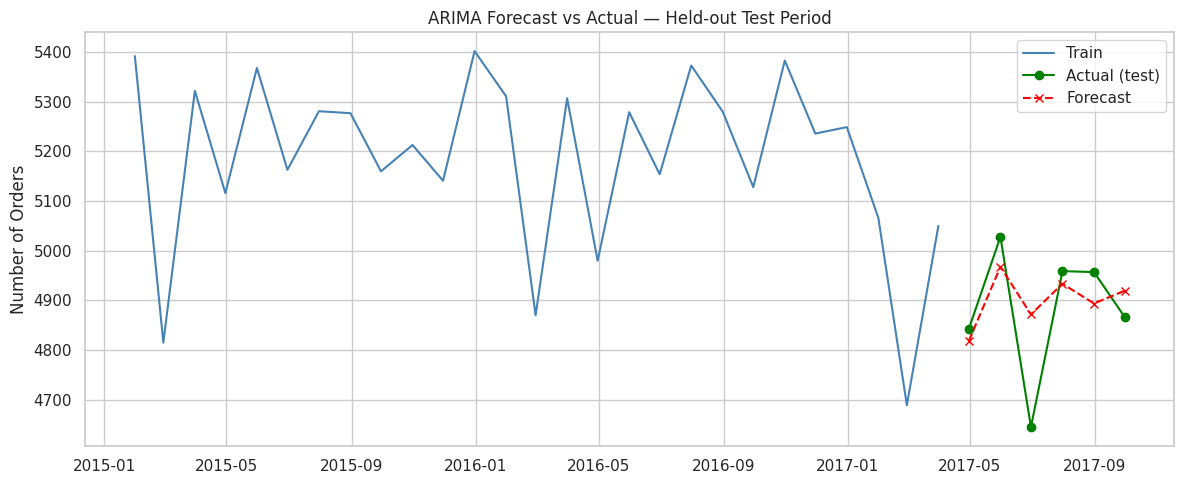

In [ ]:
# Visualize actual vs forecast on the held-out test period
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index, test.values, label='Actual (test)', color='green', marker='o')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--', marker='x')
plt.title('ARIMA Forecast vs Actual — Held out Test Period')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

### Forecasting forward: next quarter

After validating the model against real held-out data, we refit on the *full* reliable
series and forecast what should we expect next quarter

Forecasted order volume for next quarter:
2017-10-31    4931.207982
2017-11-30    4892.550668
2017-12-31    4915.824845
Freq: ME, Name: predicted_mean, dtype: float64


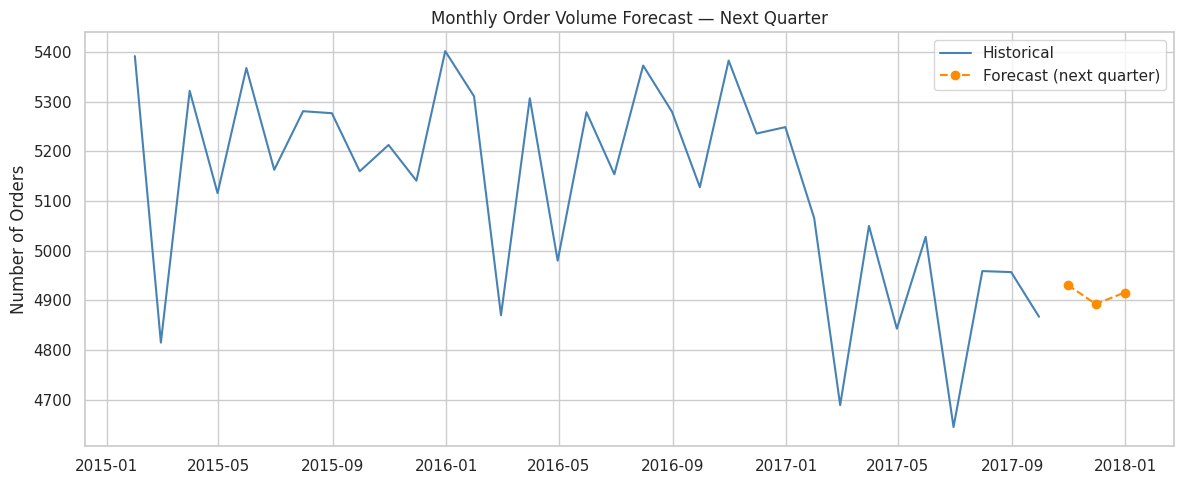

In [19]:
final_model = ARIMA(monthly_orders_reliable, order=(1, 1, 1))
final_fit = final_model.fit()

next_quarter_forecast = final_fit.forecast(steps=3)
print("Forecasted order volume for next quarter:")
print(next_quarter_forecast)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders_reliable.index, monthly_orders_reliable.values, label='Historical', color='steelblue')
plt.plot(next_quarter_forecast.index, next_quarter_forecast.values, label='Forecast (next quarter)',
         color='darkorange', marker='o', linestyle='--')
plt.title('Monthly Order Volume Forecast — Next Quarter')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

## Executive Summary & Recommendations

**Headline finding:** 54.8% of all orders in this dataset were delivered late, and
~$20.1M (54.7% of total revenue) sits in those late orders. This isn't a minor
operational hiccup — it's the majority outcome, not the exception.

**Root cause:** Late delivery rate is nearly identical across every region and market
(54-58%), but varies sharply by shipping mode — First Class has the worst late rate
(95.3%) of any option, including the cheapest one. This points to the problem being
systemic (a scheduling or fulfillment-promise issue), not a specific warehouse or
region falling behind. A fix aimed at one geography wouldn't address the core issue;
a fix aimed at how delivery windows are promised and scheduled would.

**Financial framing:** Even a 10% improvement in on-time rate would recover roughly
$2M in at-risk revenue, based on the current $20.1M exposure — a concrete number to
justify operational investment.

**Forecast use case:** The next-quarter order volume forecast (from the ARIMA model)
gives operations and staffing teams a planning baseline — useful for questions like
whether current warehouse/carrier capacity can handle expected volume, independent of
the late-delivery issue itself.

